# DIGITAL OPTIONS

## Theory

### What is a Digital Option?

A digital option (also called binary option) pays a fixed amount if the underlying finishes above (call) or below (put) the strike at expiry, and zero otherwise. Unlike a vanilla option, the payoff is discontinuous — it's all or nothing.

*Who uses it and why?*

- Used to express a directional view with a defined, capped payout
- Building block for more complex structured products
- Traders use them to hedge binary events (earnings, central bank decisions)

### Payoff

$$C_{digital} = \begin{cases} 1 & \text{if } S_T \geq K \\ 0 & \text{otherwise} \end{cases}$$

$$P_{digital} = \begin{cases} 1 & \text{if } S_T \leq K \\ 0 & \text{otherwise} \end{cases}$$

### Pricing - Black-Scholes-Merton

$$C_{digital} = e^{-rT} N(d_2)$$
$$P_{digital} = e^{-rT} N(-d_2)$$

where $d_2$​ is the same as in BSM. Intuition: $N(d_2)$ is exactly the risk-neutral probability of finishing in the money — which is precisely what the digital pays.

----

### What is a One-Touch Option?

A one-touch option is essentially a digital option where the barrier condition is monitored
continuously throughout the life of the option, rather than only at expiry.

- **Digital**: $S_T \geq K$ checked at expiry only
- **One-touch**: $S_t \geq H$ checked at every $t \leq T$

This makes the one-touch more likely to pay out than the equivalent digital, and therefore more expensive.

*Who uses it and why?*

- Used by FX desks to express views on whether a level will be touched
- Cheaper than a vanilla for directional bets when the barrier is far from spot
- Common in structured FX products and retail derivatives platforms

### Payoff

**Up-and-In:**
$$\text{Payoff} = \begin{cases} 1 & \text{if } \max_{t \leq T} S_t \geq H \\ 0 & \text{otherwise} \end{cases}$$

**Down-and-In:**
$$\text{Payoff} = \begin{cases} 1 & \text{if } \min_{t \leq T} S_t \leq H \\ 0 & \text{otherwise} \end{cases}$$

### Pricing — Reflection Principle (No Drift)

In the driftless case ($r = q = 0$), the probability that a Brownian motion hits a barrier $H$ 
before time $T$ can be derived analytically using the **reflection principle**: any path that 
crosses the barrier can be reflected at the barrier to create a bijection with paths ending 
beyond $H$ at time $T$. This gives:

$$P_{one-touch} = 2 \cdot N\left(\frac{-|\ln(H/S)|}{\sigma\sqrt{T}}\right)$$

In the general risk-neutral case (with drift), the reflection argument no longer applies directly 
and the full closed-form formula must be used instead.

### Pricing — Risk-Neutral Closed Form

**Up-and-In:**
$$P = \left(\frac{H}{S}\right)^{\lambda + \mu} N(d_1) + \left(\frac{H}{S}\right)^{\lambda - \mu} N(d_2)$$

**Down-and-In:**
$$P = \left(\frac{S}{H}\right)^{\lambda + \mu} N(d_1) + \left(\frac{S}{H}\right)^{\lambda - \mu} N(d_2)$$

where:

$$\mu = \frac{r - q - \frac{1}{2}\sigma^2}{\sigma}, \quad \lambda = \sqrt{\mu^2 + \frac{2r}{\sigma^2}}$$

$$d_1 = \frac{\ln(H/S) + \lambda \sigma T}{\sigma\sqrt{T}}, \quad d_2 = \frac{\ln(H/S) - \lambda \sigma T}{\sigma\sqrt{T}}$$

### Key intuition

- The one-touch is always more expensive than the equivalent digital since it only requires the barrier to be touched at any point, not necessarily at expiry
- The closer $H$ is to $S$, the higher the probability of touching and the more expensive the option
- As $T \to \infty$, the one-touch price approaches 1 — given enough time, the barrier will almost surely be hit

In [1]:
from black_scholes_pricer import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
S, K, r, sigma, T, q = 100, 100, 0.05, 0.2, 1, 0.03

In [3]:
closed_form = BS_Analytical()
monte_carlo = BS_MonteCarlo()

In [4]:
digital_call_option = DigitalOption(S, K, r, sigma, T, q, option_type='call')
one_touch_call_option = OneTouchOption(S, K, r, sigma, T, q, option_type='call')

digital_put_option = DigitalOption(S, K, r, sigma, T, q, option_type='put')
one_touch_put_option = OneTouchOption(S, K, r, sigma, T, q, option_type='put')

In [5]:
print(f'Digital Call Option Price using closed form solution: {closed_form.digital_option_price(digital_call_option):.2f}')
print(f'Digital Put Option Price using closed form solution: {closed_form.digital_option_price(digital_put_option):.2f}')
print('')
print(f'One-Touch Call Option Price using closed form solution: {closed_form.one_touch_option_price(one_touch_call_option):.2f}')
print(f'One-Touch Put Option Price using closed form solution: {closed_form.one_touch_option_price(one_touch_put_option):.2f}')

Digital Call Option Price using closed form solution: 0.41
Digital Put Option Price using closed form solution: 0.59

One-Touch Call Option Price using closed form solution: 0.99
One-Touch Put Option Price using closed form solution: 0.99


In [6]:
print(f'Digital Call Option Price using Monte Carlo simulations: {monte_carlo.digital_option_price(digital_call_option):.2f}')
print(f'Digital Put Option Price using Monte Carlo simulations: {monte_carlo.digital_option_price(digital_put_option):.2f}')
print('')
print(f'One-Touch Call Option Price using Monte Carlo simulations: {monte_carlo.one_touch_option_price(one_touch_call_option):.2f}')
print(f'One-Touch Put Option Price using Monte Carlo simulations: {monte_carlo.one_touch_option_price(one_touch_put_option):.2f}')

Digital Call Option Price using Monte Carlo simulations: 0.42
Digital Put Option Price using Monte Carlo simulations: 0.58

One-Touch Call Option Price using Monte Carlo simulations: 0.94
One-Touch Put Option Price using Monte Carlo simulations: 0.96


## Sensitivities

### Price vs Spot

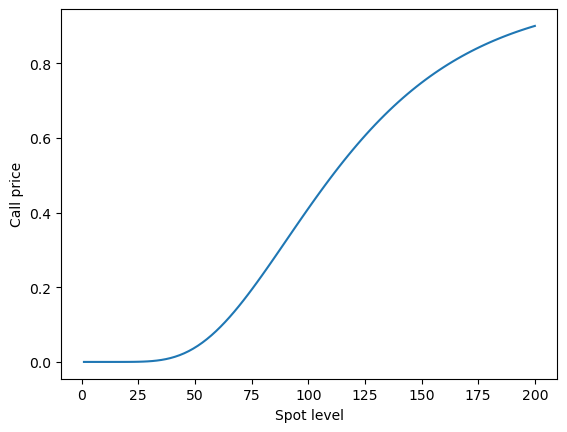

In [7]:
spot_range = np.linspace(S*0.01, S*2, 100)

digital_call_option = DigitalOption(spot_range, K, r, sigma, T, q, option_type='call')
digital_call_price = closed_form.digital_option_price(digital_call_option)

plt.plot(spot_range, digital_call_price)
plt.xlabel('Spot level')
plt.ylabel('Call price')
plt.show()

### Price vs Vol

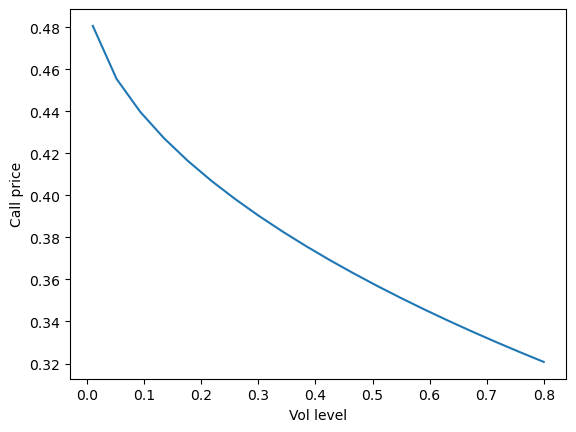

In [8]:
vol_range = np.linspace(0.01, 0.8, 20)

digital_call_option = DigitalOption(S, K, r, vol_range, T, q, option_type='call')
digital_call_price = closed_form.digital_option_price(digital_call_option)

plt.plot(vol_range, digital_call_price)
plt.xlabel('Vol level')
plt.ylabel('Call price')
plt.show()

### Price vs TTM

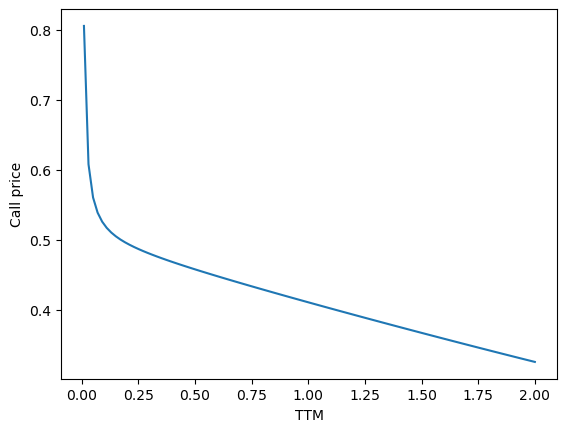

In [9]:
ttm_range = np.linspace(T*0.01, T*2, 100)

digital_call_option = DigitalOption(S, K, r, sigma, ttm_range, q, option_type='call')
digital_call_price = closed_form.digital_option_price(digital_call_option)

plt.plot(ttm_range, digital_call_price)
plt.xlabel('TTM')
plt.ylabel('Call price')
plt.show()

In [10]:
digital_call_option = DigitalOption(S, K, r, sigma, T, q, option_type='call')
digital_call_greeks = closed_form.digital_option_greeks(digital_call_option)

for i, val in digital_call_greeks.items():
    print(i + ': ', round(val,2))

Delta:  0.01
Gamma:  -0.0
Vega:  -0.0
Theta:  0.0
Rho:  0.01


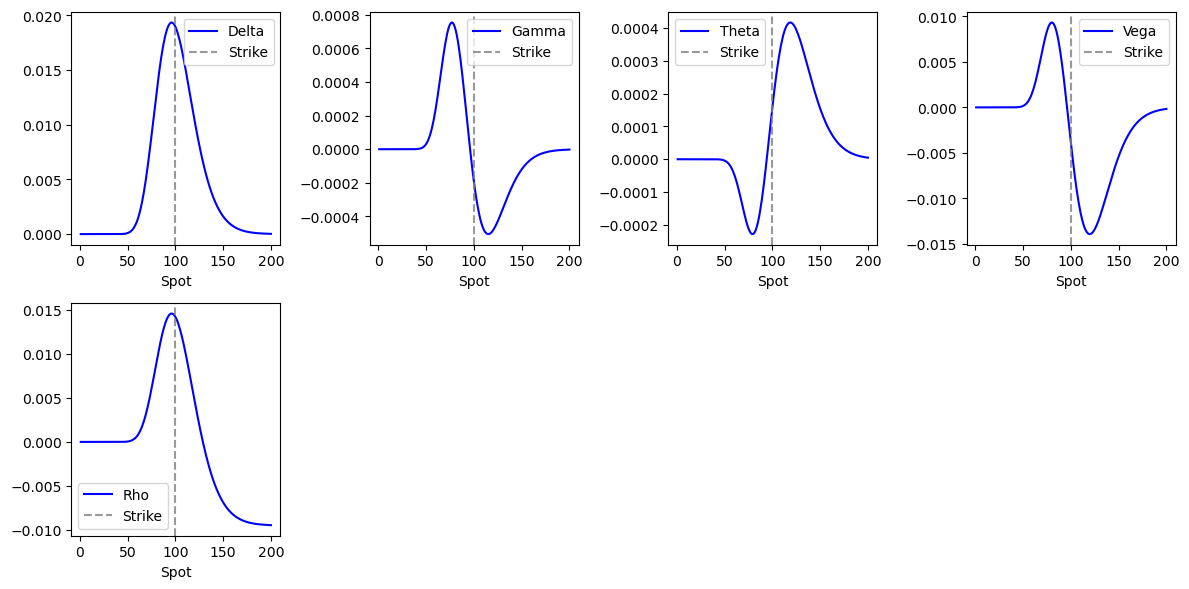

In [11]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']

val = {j: [] for j in metrics}

for i in spot_range:
    option = DigitalOption(i, K, r, T, sigma, q, 'call')
    greeks = closed_form.digital_option_greeks(option)
    for j in metrics:
        val[j].append(greeks[j])

plt.figure(figsize=(12,6))

for idx, i in enumerate(val):
    plt.subplot(2, 4, idx+1)
    plt.plot(spot_range, val[i], label=i, color='blue')
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.xlabel('Spot')
    plt.legend()

plt.tight_layout()
plt.show()

## Convergence

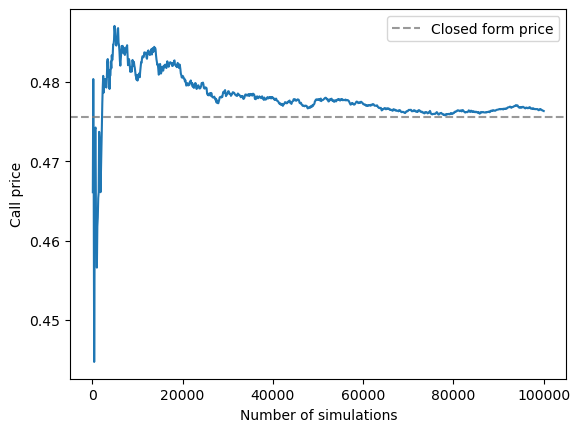

In [12]:
nb_sim = np.linspace(100, 100_000, 1000)
nb_sim = [int(i) for i in nb_sim]
prices = []

for i in nb_sim:
    option = DigitalOption(S, K, r, T, sigma, q, 'call', nb_sim=i)
    price = monte_carlo.digital_option_price(option)
    prices.append(price)

closed_form_price = closed_form.digital_option_price(option)

plt.plot(nb_sim, prices)
plt.xlabel('Number of simulations')
plt.ylabel('Call price')
plt.axhline(closed_form_price, linestyle='dashed', color='grey', alpha=0.8, label='Closed form price')
plt.legend()
plt.show()

### Digital vs One-Touch 

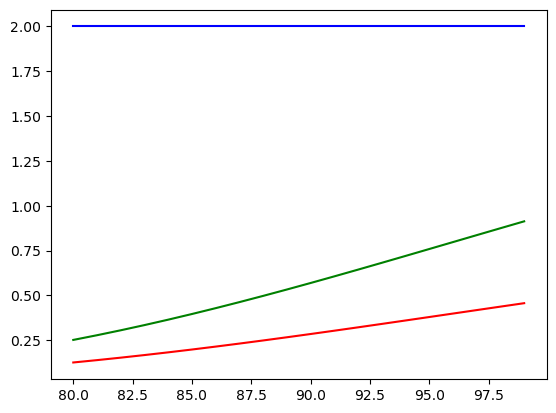

In [13]:
spot_range = np.linspace(start=S*0.8, stop=S*0.99, num=20)
diff = []

digital_call_prices = []
one_touch_call_prices = []

for i in spot_range:
    digital_call_option = DigitalOption(i, K, r, T, sigma, q, 'call')
    digital_call_price = closed_form.digital_option_price(digital_call_option)
    digital_call_prices.append(digital_call_price)

    one_touch_call_option = OneTouchOption(i, K, r, T, sigma, q, 'call', paid_at_maturity=True)
    one_touch_call_price = closed_form.one_touch_option_price(one_touch_call_option)
    one_touch_call_prices.append(one_touch_call_price)

    diff.append(one_touch_call_price / digital_call_price)

plt.plot(spot_range, diff, color='blue')
plt.plot(spot_range, digital_call_prices, color='red')
plt.plot(spot_range, one_touch_call_prices, color='green')
plt.show()

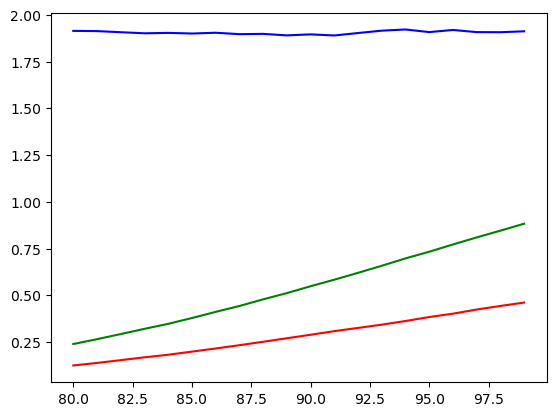

In [14]:
spot_range = np.linspace(start=S*0.8, stop=S*0.99, num=20)
diff = []

digital_call_prices = []
one_touch_call_prices = []

for i in spot_range:
    digital_call_option = DigitalOption(i, K, r, T, sigma, q, 'call')
    digital_call_price = monte_carlo.digital_option_price(digital_call_option)
    digital_call_prices.append(digital_call_price)

    one_touch_call_option = OneTouchOption(i, K, r, T, sigma, q, 'call', paid_at_maturity=True)
    one_touch_call_price = monte_carlo.one_touch_option_price(one_touch_call_option)
    one_touch_call_prices.append(one_touch_call_price)

    diff.append(one_touch_call_price / digital_call_price)

plt.plot(spot_range, diff, color='blue')
plt.plot(spot_range, digital_call_prices, color='red')
plt.plot(spot_range, one_touch_call_prices, color='green')
plt.show()